# Ad Safety: Reproducible Multi-Technique Moderation Pilot

**Team:** Swarnaditya Maitra, Vijay Agnihotri, Myetchae Thu, and Bickramjit Basu  
**Course:** MS_DSP_462 Computer Vision

This notebook is the executable technical record for a bounded static-ad
moderation pilot. It combines a frozen visual classifier, optional
open-vocabulary object evidence, OCR cues, and a deterministic policy
engine. Every reported measurement is read from saved evaluation
artifacts. The notebook fails at the evidence gate when those artifacts
are absent, rather than displaying invented placeholders.

The pilot does **not** prove fraud, legality, intent, production safety,
fairness, or adversarial robustness.


## 1. Objective, questions, and success criteria

I evaluate five questions:

1. Does a ViT frozen-backbone policy head outperform the CNN comparison on
   the same leakage-controlled split?
2. What errors occur for Safe, Firearms, Explosives, and Financial
   Promotion images?
3. Can detector and OCR cues support auditable review without being
   treated as policy truth?
4. Do the saved results satisfy proposal targets for macro F1,
   Safe-class precision, and per-class restricted recall, while also
   meeting the separate Safe-ad restricted-threshold crossing guardrail?
5. Which latency, concurrent-throughput, and MPS resource targets were
   measured, and which remain unassessed?

Proposal targets are **macro F1 > 0.93**, **Safe-class precision > 0.98**,
**per-class restricted recall > 0.95**, **latency < 50 ms per asset**,
strong concurrent-load throughput, and minimal MPS resource use. The
project separately tracks a **Safe-ad restricted-threshold crossing rate
< 0.02** as an operational guardrail. The validation recall floor of **>= 0.90**
used during threshold selection is a tuning rule, not the proposal's
> 0.95 per-class acceptance target. These are targets, not claims. Result
cells assess them only when an unambiguous measured field exists.


## 2. Reproducible setup

Run this notebook with the working directory set to the repository root. Dependencies
belong in the project environment described by `requirements.txt`; the
notebook deliberately contains no package-install cells.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import random
import re
import subprocess
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "ad_safety").is_dir():
    raise RuntimeError(
        "Start Jupyter from the repository root so Path.cwd() contains "
        "src/ad_safety, data, models, and outputs."
    )

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".mpl-cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(PROJECT_ROOT / ".cache"))
os.environ.setdefault("HF_HOME", str(PROJECT_ROOT / ".cache" / "huggingface"))
warnings.filterwarnings("ignore", message="IProgress not found.*")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import Image as NotebookImage
from IPython.display import display
from PIL import Image

from ad_safety.features import CNN_MODEL_NAME, VIT_MODEL_NAME, select_device
from ad_safety.policy import PolicyEngine

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = select_device("auto")
environment = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "torch": torch.__version__,
    "device": str(device),
    "mps_available": bool(torch.backends.mps.is_available()),
    "cuda_available": bool(torch.cuda.is_available()),
    "seed": SEED,
}
display(pd.DataFrame([environment]))


,python,platform,torch,device,mps_available,cuda_available,seed
0,3.10.14,macOS-26.5.2-arm64-arm-64bit,2.12.1,mps,True,False,42


## 3. Problem definition, policy boundary, and ethics

The system triages static JPEG, PNG, or WebP advertisements into four
visual policy categories. Firearms and explosives can cross a validated
block threshold. Financial promotion remains a review category because an
image cannot establish fraud, legality, or jurisdiction. Ambiguous cases
should reach a person rather than receive an automatic approval.

The formal capstone benchmark is small and bounded. It combines synthetic
advertising creatives with externally sourced weapon imagery and separates
source groups before training. It is not representative of live ad traffic.
Repository revisions, source groups, license evidence, hashes, synthetic
status, and audit state remain part of the evidence record. Wikimedia
examples are reserved for a separately labeled external diagnostic. OCR
text and detector boxes are supporting cues only. Occlusion maps are
qualitative sensitivity views, not causal explanations.


In [3]:
POLICY_PATH = PROJECT_ROOT / "configs" / "policy.yaml"
if not POLICY_PATH.is_file():
    raise FileNotFoundError(f"Missing policy configuration: {POLICY_PATH}")

policy_config = yaml.safe_load(POLICY_PATH.read_text(encoding="utf-8"))
policy_summary = pd.DataFrame(
    [
        {
            "label": label,
            "display_name": policy_config["label_display_names"].get(label, label),
            "default_action": policy_config["actions"].get(label, "UNSPECIFIED"),
            "threshold": policy_config["default_thresholds"].get(label),
        }
        for label in policy_config["model_labels"]
    ]
)
display(policy_summary)
configured_limitations = list(policy_config.get("limitations", []))
legacy_dataset_wording = [
    limitation
    for limitation in configured_limitations
    if "wikimedia benchmark" in str(limitation).casefold()
]
print("Configuration limitations:")
for limitation in configured_limitations:
    prefix = (
        "[LEGACY DATASET WORDING; NOT THIS FORMAL EVALUATION] "
        if limitation in legacy_dataset_wording
        else ""
    )
    print(f"- {prefix}{limitation}")
if legacy_dataset_wording:
    print(
        "Formal evaluation source: data/capstone_registry.csv. "
        "Wikimedia is reserved for an optional, separately labeled "
        "external diagnostic."
    )


,label,display_name,default_action,threshold
0,safe,Safe / general advertising,APPROVE,0.50
1,firearms,Firearms and ammunition,BLOCK,0.65
2,explosives,Explosives and explosive devices,BLOCK,0.65
3,financial_promotion,Financial or cryptocurrency promotion,REVIEW,0.40


Configuration limitations:
- Financial-promotion imagery is not proof of fraud, illegality, or regulatory status.
- Open-vocabulary Grounding DINO cues do not cover firearms or explosives comprehensively and remain uncalibrated outside the pilot domain.
- Attention and occlusion maps are qualitative evidence, not causal explanations.
- Formal metrics apply only to the source-confounded 288-image capstone benchmark and do not establish production readiness.
- The separate Wikimedia spot check is diagnostic evidence of domain shift, not a formal test set.


## 4. Rebuild controls and project scripts

Normal report execution reuses the versioned dataset, model artifact, and
evaluation files. Expensive or networked rebuild steps are opt-in through
environment variables. This keeps a routine report run deterministic while
preserving a callable path to the project scripts.


In [4]:
def run_project_script(relative_path: str, *arguments: str) -> None:
    script = PROJECT_ROOT / relative_path
    if not script.is_file():
        raise FileNotFoundError(f"Required project script does not exist: {relative_path}")
    command = [sys.executable, str(script), *arguments]
    print("Running:", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)


if os.getenv("AD_SAFETY_REBUILD_DATA", "0") == "1":
    run_project_script("scripts/build_capstone_dataset.py")

if os.getenv("AD_SAFETY_REDOWNLOAD_MODELS", "0") == "1":
    run_project_script("scripts/download_models.py")

if os.getenv("AD_SAFETY_REBUILD_EVALUATION", "0") == "1":
    combined = PROJECT_ROOT / "scripts" / "train_and_evaluate.py"
    train = PROJECT_ROOT / "scripts" / "train_models.py"
    evaluate = PROJECT_ROOT / "scripts" / "evaluate.py"
    if combined.is_file():
        run_project_script("scripts/train_and_evaluate.py")
    elif train.is_file() and evaluate.is_file():
        run_project_script("scripts/train_models.py")
        run_project_script("scripts/evaluate.py")
    else:
        raise FileNotFoundError(
            "AD_SAFETY_REBUILD_EVALUATION=1 requires either "
            "scripts/train_and_evaluate.py or both scripts/train_models.py "
            "and scripts/evaluate.py."
        )

if os.getenv("AD_SAFETY_RUN_EXTERNAL_DIAGNOSTIC", "0") == "1":
    run_project_script("scripts/evaluate_external_spot_check.py")

print("Rebuild flags are opt-in; this run will read existing artifacts.")


Rebuild flags are opt-in; this run will read existing artifacts.


## 5. Dataset provenance and exploratory analysis

The registry is the source of truth. EDA below derives counts and visuals
from the current registry, so no sample totals are embedded in prose.


In [5]:
REGISTRY_PATH = PROJECT_ROOT / "data" / "capstone_registry.csv"
if not REGISTRY_PATH.is_file():
    raise FileNotFoundError(
        f"Missing formal training registry: {REGISTRY_PATH}. "
        "Run scripts/build_capstone_dataset.py before this notebook."
    )

registry = pd.read_csv(REGISTRY_PATH)
DATASET_MANIFEST_PATH = PROJECT_ROOT / "data" / "capstone_dataset" / "dataset_manifest.json"
if not DATASET_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"Missing dataset manifest: {DATASET_MANIFEST_PATH}")
dataset_manifest = json.loads(DATASET_MANIFEST_PATH.read_text(encoding="utf-8"))
required_registry_columns = {
    "sample_id", "label", "split", "local_path", "source_dataset",
    "source_revision", "source_group", "raw_image_sha256",
    "local_sha256", "perceptual_dhash", "declared_license",
    "is_synthetic", "width", "height", "label_audit_status",
}
missing_columns = sorted(required_registry_columns - set(registry.columns))
if missing_columns:
    raise ValueError(f"Dataset registry is missing columns: {missing_columns}")

resolved_paths = registry["local_path"].map(lambda value: PROJECT_ROOT / str(value))
missing_images = [str(path.relative_to(PROJECT_ROOT)) for path in resolved_paths if not path.is_file()]
if missing_images:
    preview = "\n".join(f"  - {item}" for item in missing_images[:20])
    raise FileNotFoundError(f"Registry references missing image files:\n{preview}")

profile = {
    "registered_images": int(len(registry)),
    "labels": int(registry["label"].nunique()),
    "splits": int(registry["split"].nunique()),
    "source_datasets": int(registry["source_dataset"].nunique()),
    "licenses": int(registry["declared_license"].fillna("UNDECLARED").nunique()),
    "synthetic_images": int(
        registry["is_synthetic"].astype(str).str.casefold().eq("true").sum()
    ),
    "without_independent_label_audit": int(
        (~registry["label_audit_status"].fillna("").str.casefold().eq("approved")).sum()
    ),
}
display(pd.DataFrame([profile]))
display(pd.crosstab(registry["label"], registry["split"], margins=True))
display(
    registry.assign(declared_license=registry["declared_license"].fillna("UNDECLARED"))
    .groupby(["source_dataset", "declared_license", "is_synthetic"], dropna=False)
    .size()
    .rename("images")
    .sort_values(ascending=False)
    .reset_index()
)
display(pd.DataFrame(dataset_manifest.get("sources", [])))
print("Dataset-manifest limitations:")
for limitation in dataset_manifest.get("known_limitations", []):
    print(f"- {limitation}")


,registered_images,labels,splits,source_datasets,licenses,synthetic_images,without_independent_label_audit
0,288,4,3,3,3,144,288


split,test,train,val,All
label,,,,
explosives,12,48,12,72
financial_promotion,12,48,12,72
firearms,12,48,12,72
safe,12,48,12,72
All,48,192,48,288


,source_dataset,declared_license,is_synthetic,images
0,rajshivanshuu/weapons_set1,OSL-3.0,False,144
1,EthanGabis/ADautoGen-DS,MIT,True,72
2,project_generated_financial_creatives_v1,project-generated; release terms not declared,True,72


,declared_synthetic,license,license_scope,parquet_sha256,repo_id,revision,url,synthetic_flag_caveat
0,True,MIT,README-level,94eb1dad55a1d4e734529eaa7d96c7be8db31fdc8d7c03...,EthanGabis/ADautoGen-DS,fa7a7803265fc97926d7fab694bfc1e05c1fc7b4,https://huggingface.co/datasets/EthanGabis/ADa...,NaN
1,False,OSL-3.0,repository metadata only; per-image provenance...,NaN,rajshivanshuu/weapons_set1,d4d9dbc8272958820a3f6757e4c48d8987300271,https://huggingface.co/datasets/rajshivanshuu/...,absence of a declaration is not proof that eve...
2,True,release terms not declared,NaN,NaN,project_generated_financial_creatives_v1,e5635c7ddfc9fb3e7ff6332ba68152884b42eb45990e93...,NaN,NaN


Dataset-manifest limitations:
- Class labels are confounded with data source and generator style.
- weapons_set1 provides no per-image origin or rights metadata.
- The financial class is code-generated and does not represent real ad-platform diversity.
- ADautoGen images are Stable Diffusion v1.5 outputs, not real submitted ads.
- Source labels were not independently expert-audited image by image.


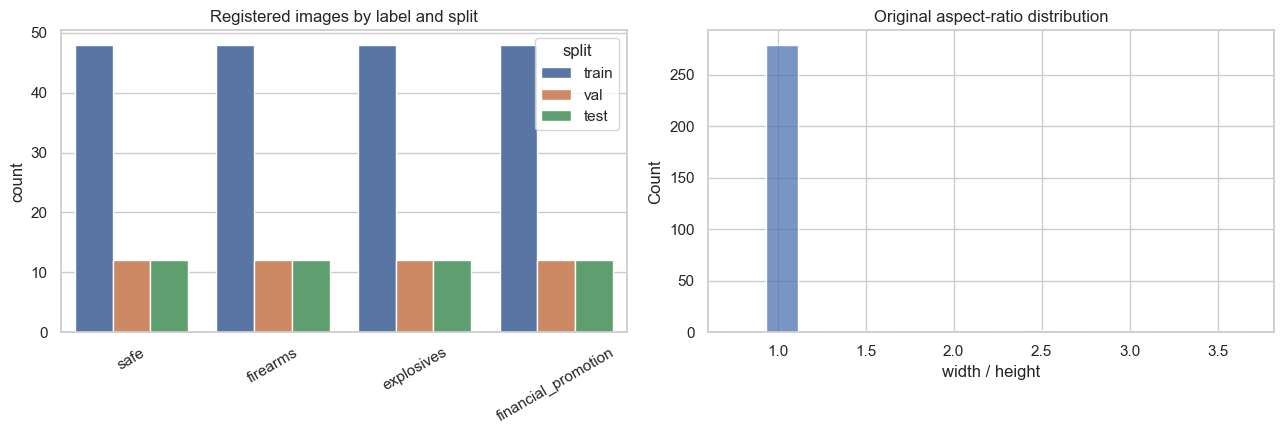

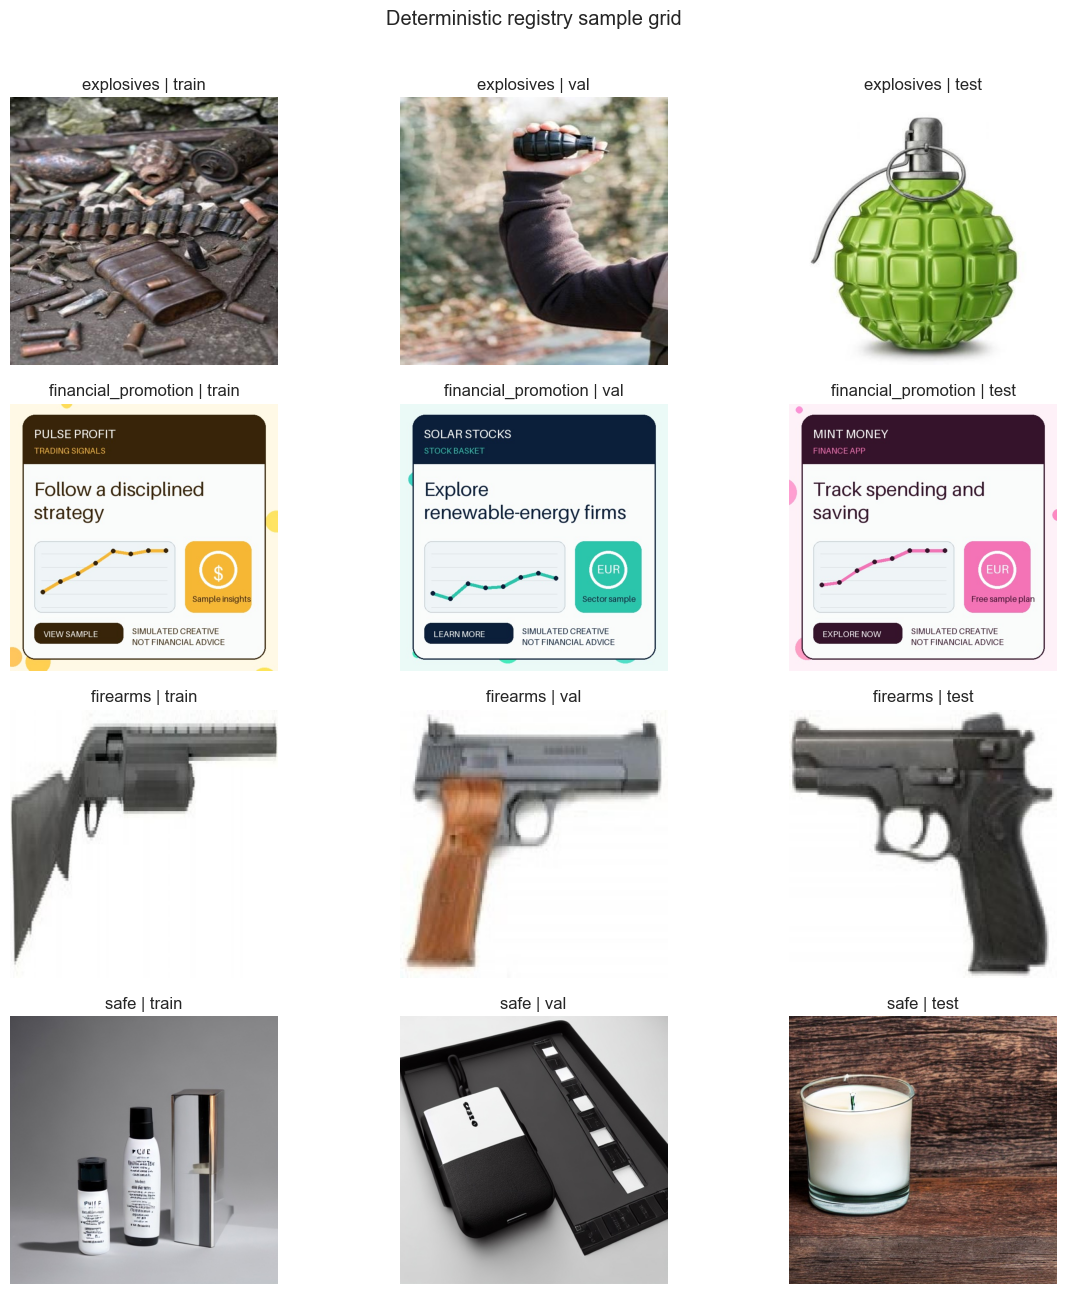

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
split_order = [item for item in ("train", "val", "test") if item in set(registry["split"])]

sns.countplot(data=registry, x="label", hue="split", hue_order=split_order, ax=axes[0])
axes[0].set_title("Registered images by label and split")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_xlabel("")

aspect_ratio = registry["width"].astype(float) / registry["height"].astype(float)
sns.histplot(aspect_ratio, bins=min(16, max(4, len(registry) // 2)), ax=axes[1])
axes[1].set_title("Original aspect-ratio distribution")
axes[1].set_xlabel("width / height")
plt.tight_layout()
plt.show()

labels = sorted(registry["label"].astype(str).unique())
splits = [item for item in ("train", "val", "test") if item in set(registry["split"])]
fig, axes = plt.subplots(
    len(labels), len(splits),
    figsize=(4.2 * len(splits), 3.2 * len(labels)),
    squeeze=False,
)
for row_index, label in enumerate(labels):
    for column_index, split in enumerate(splits):
        axis = axes[row_index, column_index]
        candidates = registry.loc[
            registry["label"].eq(label) & registry["split"].eq(split)
        ].sort_values("sample_id")
        if candidates.empty:
            axis.text(0.5, 0.5, "No registered sample", ha="center", va="center")
        else:
            sample_path = PROJECT_ROOT / str(candidates.iloc[0]["local_path"])
            with Image.open(sample_path) as sample:
                axis.imshow(sample.convert("RGB"))
        axis.set_title(f"{label} | {split}")
        axis.axis("off")
plt.suptitle("Deterministic registry sample grid", y=1.01)
plt.tight_layout()
plt.show()


## 6. Leakage controls and split coverage

Exact local and raw hashes, perceptual hashes, and source groups must not
cross train, validation, and test. Class coverage and source-group counts
are shown separately because a technically clean split can still be too
small or too narrow for reliable generalization.


In [7]:
leakage_rows = []
for identity_column in (
    "local_sha256", "raw_image_sha256", "perceptual_dhash", "source_group"
):
    usable = registry.loc[registry[identity_column].fillna("").astype(str).str.len() > 0]
    split_counts = usable.groupby(identity_column)["split"].nunique()
    for identity in split_counts[split_counts > 1].index:
        rows = usable.loc[usable[identity_column] == identity]
        leakage_rows.append(
            {
                "identity_type": identity_column,
                "identity": identity,
                "splits": ", ".join(sorted(rows["split"].astype(str).unique())),
                "rows": int(len(rows)),
            }
        )

leakage = pd.DataFrame(leakage_rows)
if not leakage.empty:
    display(leakage)
    raise RuntimeError(
        "Cross-split identity leakage detected. Correct the registry and rerun evaluation."
    )
print("PASS: no exact hash, perceptual-hash, or source-group identity crosses splits.")

coverage = pd.crosstab(registry["label"], registry["split"])
display(coverage)
expected_splits = {"train", "val", "test"}
coverage_gaps = [
    {"label": label, "missing_splits": ", ".join(sorted(expected_splits - set(group["split"]))) }
    for label, group in registry.groupby("label")
    if expected_splits - set(group["split"])
]
if coverage_gaps:
    print("Coverage gaps that limit class-level evaluation:")
    display(pd.DataFrame(coverage_gaps))

display(
    registry.groupby(["label", "split"])["source_group"]
    .nunique()
    .rename("distinct_source_groups")
    .reset_index()
)


PASS: no exact hash, perceptual-hash, or source-group identity crosses splits.


split,test,train,val
label,,,
explosives,12,48,12
financial_promotion,12,48,12
firearms,12,48,12
safe,12,48,12


,label,split,distinct_source_groups
0,explosives,test,12
1,explosives,train,48
2,explosives,val,12
3,financial_promotion,test,4
4,financial_promotion,train,16
5,financial_promotion,val,4
6,firearms,test,12
7,firearms,train,48
8,firearms,val,12
9,safe,test,6


## 7. Model architecture and comparison plan

The measured comparison uses frozen ImageNet-pretrained features with the
same downstream policy-head procedure and split. The selected artifact is
`models/vit_policy_head.joblib`. Grounding DINO and Tesseract remain
optional evidence paths in `ModerationEngine`; they do not override the
validated classifier block threshold. Letterboxing, EXIF correction,
transparency handling, byte limits, and pixel limits live in the project
preprocessing module.


In [8]:
MODEL_MANIFEST_PATH = PROJECT_ROOT / "models" / "pretrained_model_manifest.json"
if not MODEL_MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"Missing pretrained model manifest: {MODEL_MANIFEST_PATH}")

model_manifest = json.loads(MODEL_MANIFEST_PATH.read_text(encoding="utf-8"))
display(pd.DataFrame(model_manifest.get("models", [])))
print("ViT comparison backbone:", VIT_MODEL_NAME)
print("CNN comparison backbone:", CNN_MODEL_NAME)
print("Runtime classifier:", "models/vit_policy_head.joblib")


,repo_id,revision,local_snapshot,license,snapshot_sha256,snapshot_bytes,snapshot_files,downloads_recorded_at
0,timm/vit_base_patch16_224.augreg2_in21k_ft_in1k,063c6c38a5d8510b2e57df480445e94b231dad2c,.cache/huggingface/hub/models--timm--vit_base_...,apache-2.0,e19b7516e8c2b523f452598f6add160b8f80450f1412fe...,692616164,5,2026-08-26T10:33:26.699155+00:00
1,timm/resnet50.a1_in1k,767268603ca0cb0bfe326fa87277f19c419566ef,.cache/huggingface/hub/models--timm--resnet50....,apache-2.0,4421e496a8e63ea21d10d905320a5d8d1442996f91bed4...,205055737,5,2026-08-26T10:33:26.810587+00:00
2,IDEA-Research/grounding-dino-tiny,a2bb814dd30d776dcf7e30523b00659f4f141c71,.cache/huggingface/hub/models--IDEA-Research--...,apache-2.0,1d9b6d4538c3dfbc30cc8c1a9defeedfde8e57e540c490...,1382224246,11,2026-08-26T10:33:27.579395+00:00


ViT comparison backbone: vit_base_patch16_224.augreg2_in21k_ft_in1k
CNN comparison backbone: resnet50.a1_in1k
Runtime classifier: models/vit_policy_head.joblib


## 8. Measured-evidence gate

Execution stops here unless every contracted evaluation file and the
deployable classifier artifact exist. This prevents a partially completed
run from being presented as final evidence.


In [9]:
REQUIRED_EVALUATION_ARTIFACTS = (
    "outputs/evaluation/evaluation_metrics.json",
    "outputs/evaluation/independent_validation.json",
    "outputs/evaluation/per_class_metrics.csv",
    "outputs/evaluation/test_predictions.csv",
    "outputs/evaluation/thresholds.csv",
    "outputs/evaluation/metrics_summary.csv",
    "outputs/evaluation/benchmark_cpu_batch1.csv",
    "outputs/evaluation/split_summary.csv",
    "outputs/evaluation/output_checksums.csv",
    "outputs/evaluation/dataset_distribution.png",
    "outputs/evaluation/dataset_contact_sheet.jpg",
    "outputs/evaluation/confusion_matrix_vit.png",
    "outputs/evaluation/confusion_matrix_resnet50.png",
    "outputs/evaluation/precision_recall_curves.png",
    "outputs/evaluation/threshold_calibration.png",
    "outputs/evaluation/model_comparison.png",
)
REQUIRED_RUNTIME_ARTIFACTS = ("models/vit_policy_head.joblib",)

missing_artifacts = [
    relative
    for relative in REQUIRED_EVALUATION_ARTIFACTS + REQUIRED_RUNTIME_ARTIFACTS
    if not (PROJECT_ROOT / relative).is_file()
]
if missing_artifacts:
    missing_text = "\n".join(f"  - {path}" for path in missing_artifacts)
    raise FileNotFoundError(
        "Measured-evidence gate failed. This notebook will not create "
        "placeholder results. Missing required files:\n"
        f"{missing_text}\n"
        "Run the project training/evaluation workflow, then restart the notebook."
    )
print("PASS: all contracted evaluation and runtime artifacts exist.")


PASS: all contracted evaluation and runtime artifacts exist.


In [10]:
EVALUATION_DIR = PROJECT_ROOT / "outputs" / "evaluation"

def read_json(name: str):
    path = EVALUATION_DIR / name
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError as exc:
        raise ValueError(f"Invalid JSON in {path.relative_to(PROJECT_ROOT)}: {exc}") from exc


def flatten_json(value, prefix: str = "") -> dict[str, object]:
    flattened: dict[str, object] = {}
    if isinstance(value, dict):
        for key, child in value.items():
            child_prefix = f"{prefix}.{key}" if prefix else str(key)
            flattened.update(flatten_json(child, child_prefix))
    elif isinstance(value, list):
        flattened[prefix] = json.dumps(value, sort_keys=True)
    else:
        flattened[prefix] = value
    return flattened


metrics = read_json("evaluation_metrics.json")
independent_validation = read_json("independent_validation.json")
per_class_metrics = pd.read_csv(EVALUATION_DIR / "per_class_metrics.csv")
predictions = pd.read_csv(EVALUATION_DIR / "test_predictions.csv")
thresholds = pd.read_csv(EVALUATION_DIR / "thresholds.csv")
model_comparison = pd.read_csv(EVALUATION_DIR / "metrics_summary.csv")
benchmark = pd.read_csv(EVALUATION_DIR / "benchmark_cpu_batch1.csv")
split_summary = pd.read_csv(EVALUATION_DIR / "split_summary.csv")
output_checksums = pd.read_csv(EVALUATION_DIR / "output_checksums.csv")

if "local_path" not in predictions.columns:
    predictions = predictions.merge(
        registry[["sample_id", "local_path"]],
        on="sample_id",
        how="left",
        validate="many_to_one",
    )

primary_model_key = str(metrics.get("protocol", {}).get("primary_model_predeclared", "vit"))
model_results = metrics.get("models", [])
primary_result = next(
    (row for row in model_results if str(row.get("key")) == primary_model_key),
    None,
)
if primary_result is None:
    raise ValueError(
        f"evaluation_metrics.json has no result for predeclared primary model {primary_model_key!r}."
    )

primary_predictions = predictions.loc[predictions["model"].astype(str).eq(primary_model_key)].copy()
failure_cases = primary_predictions.loc[
    primary_predictions["true_label"].astype(str)
    .ne(primary_predictions["predicted_label"].astype(str))
].copy()

artifact_shapes = pd.DataFrame(
    [
        {"artifact": "per_class_metrics.csv", "rows": len(per_class_metrics), "columns": len(per_class_metrics.columns)},
        {"artifact": "test_predictions.csv", "rows": len(predictions), "columns": len(predictions.columns)},
        {"artifact": "thresholds.csv", "rows": len(thresholds), "columns": len(thresholds.columns)},
        {"artifact": "metrics_summary.csv", "rows": len(model_comparison), "columns": len(model_comparison.columns)},
        {"artifact": "benchmark_cpu_batch1.csv", "rows": len(benchmark), "columns": len(benchmark.columns)},
        {"artifact": "split_summary.csv", "rows": len(split_summary), "columns": len(split_summary.columns)},
        {"artifact": "derived primary-model failures", "rows": len(failure_cases), "columns": len(failure_cases.columns)},
    ]
)
display(artifact_shapes)


,artifact,rows,columns
0,per_class_metrics.csv,16,9
1,test_predictions.csv,96,12
2,thresholds.csv,6,15
3,metrics_summary.csv,2,13
4,benchmark_cpu_batch1.csv,2,13
5,split_summary.csv,12,6
6,derived primary-model failures,1,12


## 9. ViT versus CNN comparison

The table below is read directly from `metrics_summary.csv`. Model names,
scores, fit time, and latency columns are not assumed; the complete saved
schema is displayed so the comparison remains traceable.


In [11]:
if model_comparison.empty:
    raise ValueError("metrics_summary.csv exists but contains no measured rows.")
display(model_comparison)


,model,role,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,test_macro_average_precision_ovr,test_macro_roc_auc_ovr,test_log_loss,cpu_batch1_median_ms,cpu_batch1_p95_ms,feature_extraction_seconds,head_fit_seconds
0,vit,predeclared primary,0.958333,0.958042,0.979167,0.979130,1.000000,1.000000,0.083628,69.140167,71.527291,8.297698,0.008591
1,resnet50,predeclared CNN baseline,0.958333,0.957273,0.875000,0.873152,0.965961,0.986111,0.287571,38.296229,40.064395,11.119635,0.021568


## 10. Test metrics and confusion analysis

Overall and per-class results remain separate. Macro F1 alone can hide a
dangerous restricted-class miss rate, while aggregate accuracy can hide
poor behavior on a small class.


In [12]:
metrics_flat = flatten_json(
    {
        "run": metrics.get("run", {}),
        "protocol": metrics.get("protocol", {}),
        "dataset": metrics.get("dataset", {}),
        "limitations": metrics.get("limitations", []),
    }
)
metrics_table = pd.DataFrame(
    [{"metric_path": key, "measured_value": value} for key, value in metrics_flat.items()]
)
if metrics_table.empty:
    raise ValueError("evaluation_metrics.json contains no run or protocol evidence.")
display(metrics_table)

primary_test_metrics = dict(primary_result.get("test_metrics", {}))
primary_scalar_metrics = {
    key: value
    for key, value in primary_test_metrics.items()
    if isinstance(value, (int, float)) and not isinstance(value, bool)
}
display(
    pd.DataFrame(
        [
            {
                "model": primary_model_key,
                "split": "untouched test",
                **primary_scalar_metrics,
            }
        ]
    )
)

if per_class_metrics.empty:
    raise ValueError("per_class_metrics.csv exists but contains no measured rows.")
display(per_class_metrics.sort_values(["model", "split", "label"]))
display(thresholds.sort_values(["model", "label"]))


,metric_path,measured_value
0,run.actual_feature_device,cpu
1,run.cpu_threads,1
2,run.created_at_utc,2026-08-25T18:28:58.613303+00:00
3,run.hardware,Apple M2 Max
4,run.mps_available,False
5,run.mps_built,True
6,run.packages.Pillow,12.3.0
7,run.packages.joblib,1.5.3
8,run.packages.numpy,2.1.3
9,run.packages.pandas,2.3.3


,model,split,accuracy,balanced_accuracy,expected_calibration_error_10_bin,log_loss,macro_average_precision_ovr,macro_f1,macro_precision,macro_recall,macro_roc_auc_ovr,multiclass_brier,weighted_f1
0,vit,untouched test,0.979167,0.979167,0.030961,0.083628,1.0,0.97913,0.980769,0.979167,1.0,0.044303,0.97913


,model,split,label,precision,recall,f1,support,average_precision_ovr,roc_auc_ovr
14,resnet50,test,explosives,0.750000,0.750000,0.750000,12,0.922371,0.965278
15,resnet50,test,financial_promotion,1.000000,1.000000,1.000000,12,1.000000,1.000000
13,resnet50,test,firearms,0.923077,1.000000,0.960000,12,1.000000,1.000000
12,resnet50,test,safe,0.818182,0.750000,0.782609,12,0.941472,0.979167
10,resnet50,validation,explosives,1.000000,0.833333,0.909091,12,0.954365,0.979167
11,resnet50,validation,financial_promotion,1.000000,1.000000,1.000000,12,1.000000,1.000000
9,resnet50,validation,firearms,0.923077,1.000000,0.960000,12,1.000000,1.000000
8,resnet50,validation,safe,0.923077,1.000000,0.960000,12,0.970736,0.990741
6,vit,test,explosives,1.000000,0.916667,0.956522,12,1.000000,1.000000
7,vit,test,financial_promotion,1.000000,1.000000,1.000000,12,1.000000,1.000000


,model,label,threshold,selection_split,target_validation_recall,validation_precision,validation_recall,validation_f1,validation_fp,validation_fn,test_precision,test_recall,test_f1,test_fp,test_fn
4,resnet50,explosives,0.056298,validation,0.9,0.785714,0.916667,0.846154,3,1,0.631579,1.000000,0.774194,7,0
5,resnet50,financial_promotion,0.997424,validation,0.9,1.000000,1.000000,1.000000,0,0,1.000000,0.583333,0.736842,0,5
3,resnet50,firearms,0.991443,validation,0.9,1.000000,1.000000,1.000000,0,0,1.000000,0.833333,0.909091,0,2
1,vit,explosives,0.172763,validation,0.9,1.000000,1.000000,1.000000,0,0,1.000000,0.916667,0.956522,0,1
2,vit,financial_promotion,0.994603,validation,0.9,1.000000,1.000000,1.000000,0,0,1.000000,1.000000,1.000000,0,0
0,vit,firearms,0.991356,validation,0.9,1.000000,1.000000,1.000000,0,0,1.000000,0.916667,0.956522,0,1


Untouched test confusion matrix: resnet50


predicted_label,safe,firearms,explosives,financial_promotion
true_label,,,,
safe,9,0,3,0
firearms,0,12,0,0
explosives,2,1,9,0
financial_promotion,0,0,0,12


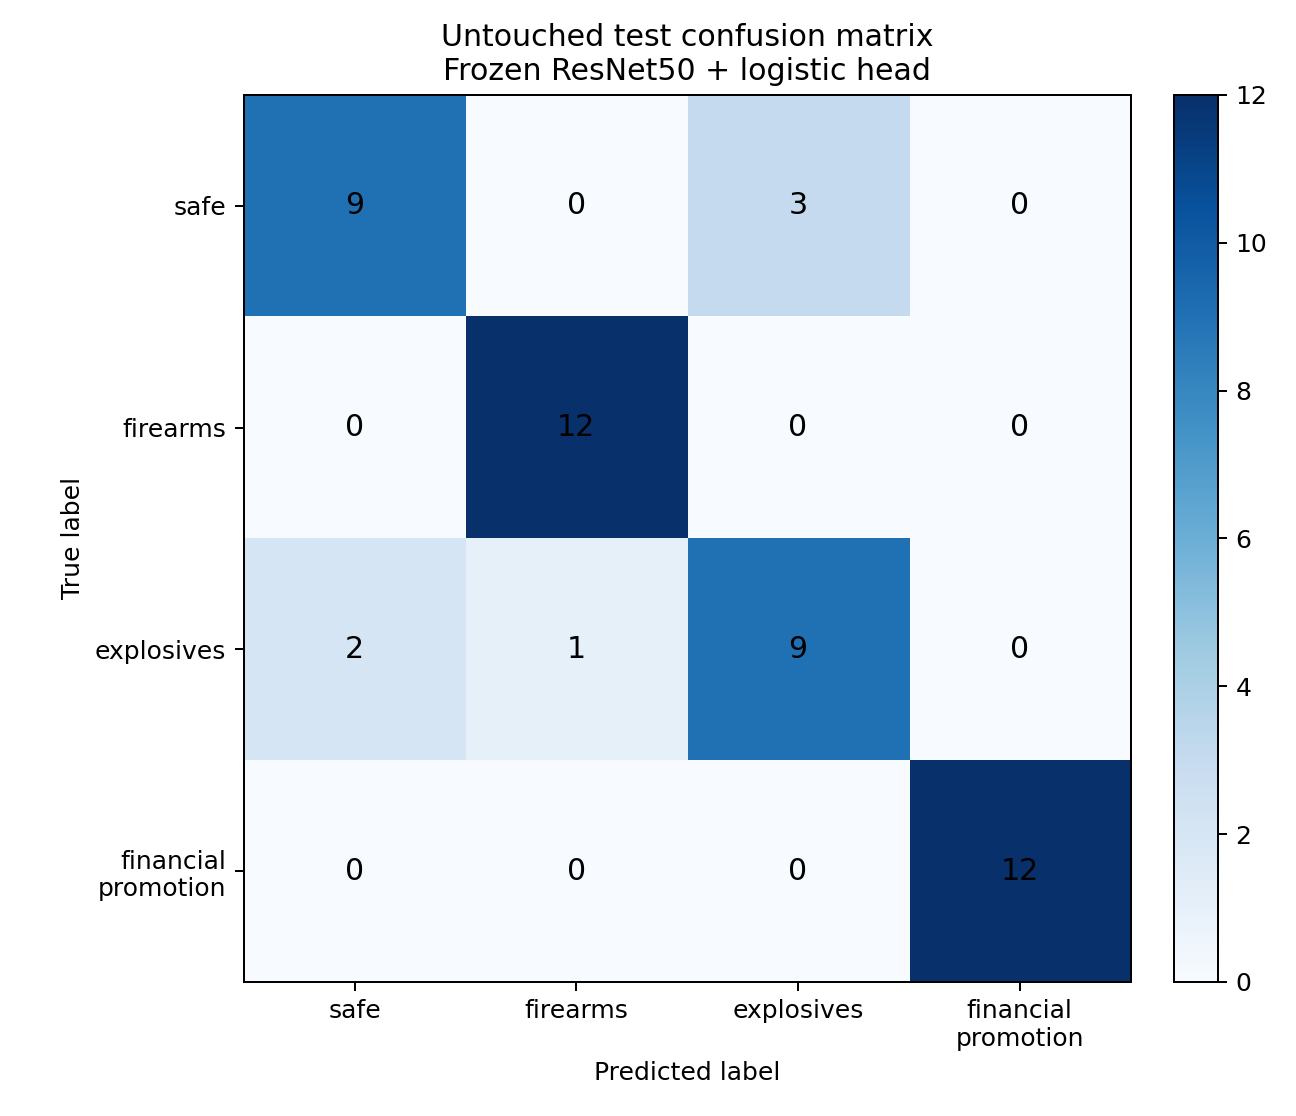

Untouched test confusion matrix: vit


predicted_label,safe,firearms,explosives,financial_promotion
true_label,,,,
safe,12,0,0,0
firearms,0,12,0,0
explosives,0,1,11,0
financial_promotion,0,0,0,12


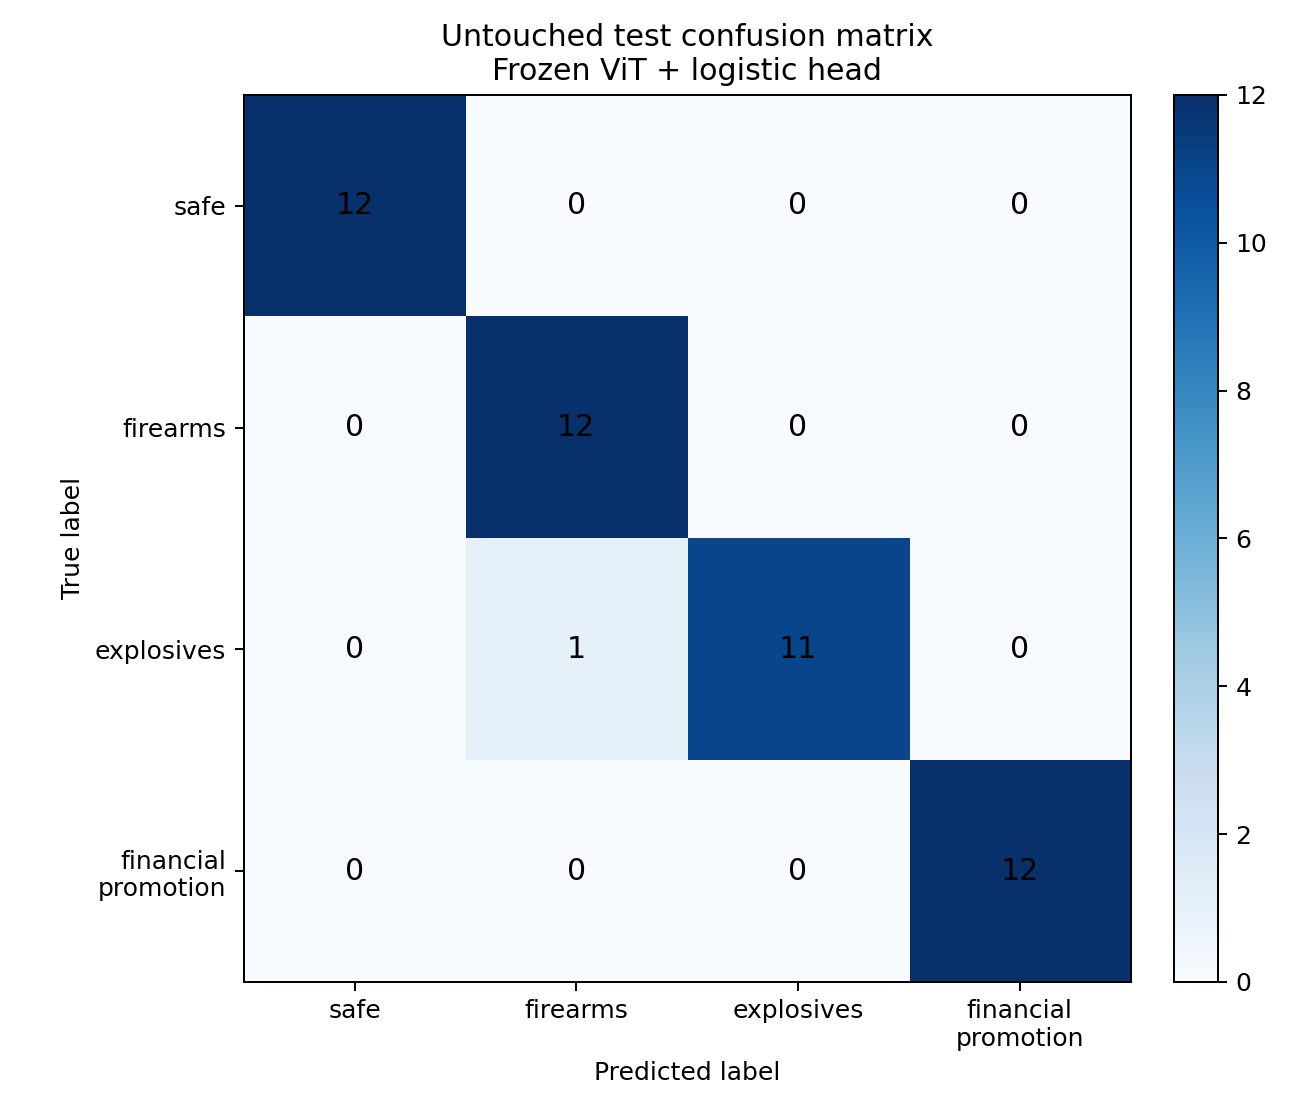

In [13]:
labels = list(policy_config["model_labels"])
for model_key in sorted(predictions["model"].astype(str).unique()):
    model_predictions = predictions.loc[predictions["model"].astype(str).eq(model_key)]
    matrix_table = pd.crosstab(
        model_predictions["true_label"],
        model_predictions["predicted_label"],
        dropna=False,
    ).reindex(index=labels, columns=labels, fill_value=0)
    print(f"Untouched test confusion matrix: {model_key}")
    display(matrix_table)
    image_path = EVALUATION_DIR / f"confusion_matrix_{model_key}.png"
    if not image_path.is_file():
        raise FileNotFoundError(f"Missing saved confusion plot: {image_path}")
    display(NotebookImage(filename=str(image_path), width=700))


In [14]:
def canonical_metric_name(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.casefold()).strip("_")


def assessed_target(
    metric: str,
    measured: float,
    target: float,
    relation: str,
    source: str,
    detail: str,
    criterion_type: str,
) -> dict[str, object]:
    passed = measured > target if relation == ">" else measured < target
    return {
        "metric": metric,
        "measured_value": measured,
        "target": f"{relation} {target}",
        "status": "PASS" if passed else "FAIL",
        "criterion_type": criterion_type,
        "source": source,
        "detail": detail,
    }


threshold_test_metrics = primary_result.get("threshold_test_metrics", {})
restricted_labels = ["firearms", "explosives", "financial_promotion"]
missing_restricted = [
    label
    for label in restricted_labels
    if not isinstance(threshold_test_metrics.get(label, {}).get("recall"), (int, float))
]
if missing_restricted:
    raise ValueError(
        f"Primary-model threshold test recall is missing for: {missing_restricted}"
    )
restricted_recalls = {
    label: float(threshold_test_metrics[label]["recall"])
    for label in restricted_labels
}
primary_threshold_rows = thresholds.loc[
    thresholds["model"].astype(str).eq(primary_model_key)
]
calibration_floor_values = sorted(
    pd.to_numeric(
        primary_threshold_rows["target_validation_recall"], errors="raise"
    ).dropna().unique()
)
if len(calibration_floor_values) != 1:
    raise ValueError(
        "Expected one validation recall floor for the primary model, found "
        f"{calibration_floor_values}."
    )
calibration_recall_floor = float(calibration_floor_values[0])
argmax_restricted_recalls = {
    label: float(primary_test_metrics["per_class"][label]["recall"])
    for label in restricted_labels
}
display(
    pd.DataFrame(
        [
            {
                "interpretation": "multiclass argmax restricted recall",
                "mean": float(np.mean(list(argmax_restricted_recalls.values()))),
                "minimum": min(argmax_restricted_recalls.values()),
                "per_class": json.dumps(argmax_restricted_recalls, sort_keys=True),
                "target_use": "descriptive aggregate",
            },
            {
                "interpretation": "validation-threshold operating recall",
                "mean": float(np.mean(list(restricted_recalls.values()))),
                "minimum": min(restricted_recalls.values()),
                "per_class": json.dumps(restricted_recalls, sort_keys=True),
                "threshold_selection_floor": f">= {calibration_recall_floor:.2f} on validation",
                "proposal_acceptance": "minimum test class compared with > 0.95",
            },
        ]
    )
)

safe_class_metrics = primary_test_metrics.get("per_class", {}).get("safe", {})
missing_safe_metrics = [
    name
    for name in ("precision", "recall")
    if not isinstance(safe_class_metrics.get(name), (int, float))
]
if missing_safe_metrics:
    raise ValueError(
        f"Primary-model Safe-class metrics are missing: {missing_safe_metrics}."
    )
safe_class_precision = float(safe_class_metrics["precision"])
safe_argmax_false_flag_rate = float(1.0 - safe_class_metrics["recall"])
safe_predictions = primary_predictions.loc[
    primary_predictions["true_label"].astype(str).eq("safe")
]
if safe_predictions.empty:
    raise ValueError("Primary-model test predictions contain no Safe examples.")

def any_threshold_flag(value: str) -> bool:
    payload = json.loads(str(value))
    if not isinstance(payload, dict):
        raise ValueError("threshold_flags must contain a JSON object.")
    return any(bool(payload.get(label, False)) for label in restricted_labels)


safe_flags = safe_predictions["threshold_flags"].map(any_threshold_flag)
safe_false_positives = int(safe_flags.sum())
safe_threshold_crossing_rate = float(safe_false_positives / len(safe_predictions))
display(
    pd.DataFrame(
        [
            {
                "measure": "Safe-class precision",
                "value": safe_class_precision,
                "definition": "true Safe among argmax predictions labeled Safe",
                "role": "proposal metric",
            },
            {
                "measure": "Safe-ad argmax false-flag rate",
                "value": safe_argmax_false_flag_rate,
                "definition": "1 - Safe recall; true Safe images assigned any non-Safe argmax label",
                "role": "descriptive diagnostic",
            },
            {
                "measure": "Safe-ad restricted-threshold crossing rate",
                "value": safe_threshold_crossing_rate,
                "definition": "true Safe images crossing at least one saved restricted threshold",
                "role": "separate project operational guardrail",
            },
        ]
    )
)
acceptance = pd.DataFrame(
    [
        assessed_target(
            "primary test macro F1",
            float(primary_test_metrics["macro_f1"]),
            0.93,
            ">",
            "evaluation_metrics.json",
            primary_model_key,
            "proposal acceptance target",
        ),
        assessed_target(
            "Safe-class precision",
            safe_class_precision,
            0.98,
            ">",
            "evaluation_metrics.json",
            "multiclass Safe precision on the untouched test split",
            "proposal acceptance target",
        ),
        assessed_target(
            "minimum restricted-class threshold recall",
            min(restricted_recalls.values()),
            0.95,
            ">",
            "evaluation_metrics.json",
            (
                f"validation selection floor >= {calibration_recall_floor:.2f}; "
                f"test recalls {json.dumps(restricted_recalls, sort_keys=True)}"
            ),
            "proposal acceptance target",
        ),
        assessed_target(
            "Safe-ad restricted-threshold crossing rate",
            safe_threshold_crossing_rate,
            0.02,
            "<",
            "test_predictions.csv",
            f"{safe_false_positives}/{len(safe_predictions)} Safe test images crossed a restricted threshold",
            "separate project operational guardrail",
        ),
    ]
)
display(acceptance)
print(
    "All measured criteria use the predeclared ViT and untouched test artifacts. "
    "The >=0.90 validation recall floor is a threshold-selection rule, not the "
    "proposal's >0.95 per-class acceptance target."
)


,interpretation,mean,minimum,per_class,target_use,threshold_selection_floor,proposal_acceptance
0,multiclass argmax restricted recall,0.972222,0.916667,"{""explosives"": 0.9166666666666666, ""financial_...",descriptive aggregate,NaN,NaN
1,validation-threshold operating recall,0.944444,0.916667,"{""explosives"": 0.9166666666666666, ""financial_...",NaN,>= 0.90 on validation,minimum test class compared with > 0.95


,measure,value,definition,role
0,Safe-class precision,1.0,true Safe among argmax predictions labeled Safe,proposal metric
1,Safe-ad argmax false-flag rate,0.0,1 - Safe recall; true Safe images assigned any...,descriptive diagnostic
2,Safe-ad restricted-threshold crossing rate,0.0,true Safe images crossing at least one saved r...,separate project operational guardrail


,metric,measured_value,target,status,criterion_type,source,detail
0,primary test macro F1,0.979130,> 0.93,PASS,proposal acceptance target,evaluation_metrics.json,vit
1,Safe-class precision,1.000000,> 0.98,PASS,proposal acceptance target,evaluation_metrics.json,multiclass Safe precision on the untouched tes...
2,minimum restricted-class threshold recall,0.916667,> 0.95,FAIL,proposal acceptance target,evaluation_metrics.json,validation selection floor >= 0.90; test recal...
3,Safe-ad restricted-threshold crossing rate,0.000000,< 0.02,PASS,separate project operational guardrail,test_predictions.csv,0/12 Safe test images crossed a restricted thr...


All measured criteria use the predeclared ViT and untouched test artifacts. The >=0.90 validation recall floor is a threshold-selection rule, not the proposal's >0.95 per-class acceptance target.


## 11. Policy fusion and decision audit

`PolicyEngine` combines classifier scores with optional OCR and detector
evidence through noisy-OR fusion. The following are deterministic unit
checks of configured behavior, not estimates of predictive performance.
Block decisions still require the corresponding classifier score to cross
its validated threshold. Financial promotion remains human review.


In [15]:
policy_engine = PolicyEngine(policy_config)
unit_cases = [
    {
        "case": "clear_safe_contract",
        "scores": {"safe": 0.92, "firearms": 0.02, "explosives": 0.02, "financial_promotion": 0.04},
        "ocr": "",
        "detections": [],
        "expected": "APPROVE",
    },
    {
        "case": "validated_firearms_threshold_contract",
        "scores": {"safe": 0.05, "firearms": 0.80, "explosives": 0.08, "financial_promotion": 0.07},
        "ocr": "",
        "detections": [],
        "expected": "BLOCK",
    },
    {
        "case": "financial_review_contract",
        "scores": {"safe": 0.28, "firearms": 0.04, "explosives": 0.03, "financial_promotion": 0.45},
        "ocr": "crypto investment",
        "detections": [],
        "expected": "REVIEW",
    },
]
unit_rows = []
for case in unit_cases:
    decision = policy_engine.decide(
        case["scores"],
        ocr_text=case["ocr"],
        detections=case["detections"],
        model_version="unit-contract-only",
    )
    assert decision.verdict == case["expected"], (case["case"], decision.verdict)
    unit_rows.append(
        {
            "case": case["case"],
            "expected": case["expected"],
            "observed": decision.verdict,
            "reason": "; ".join(decision.review_reasons),
        }
    )
display(pd.DataFrame(unit_rows))


,case,expected,observed,reason
0,clear_safe_contract,APPROVE,APPROVE,
1,validated_firearms_threshold_contract,BLOCK,BLOCK,firearms was the top classifier class and cros...
2,financial_review_contract,REVIEW,REVIEW,"OCR cue for financial_promotion: crypto, inves..."


In [16]:
if predictions.empty:
    raise ValueError("test_predictions.csv exists but contains no held-out predictions.")

audit_tokens = ("path", "true", "label", "pred", "verdict", "score", "prob", "fused", "reason")
audit_columns = [
    column for column in predictions.columns
    if any(token in column.casefold() for token in audit_tokens)
]
display(predictions[audit_columns[:16]].head(20))

verdict_columns = [column for column in predictions.columns if "verdict" in column.casefold()]
if verdict_columns:
    display(
        predictions[verdict_columns[0]]
        .value_counts(dropna=False)
        .rename_axis("verdict")
        .reset_index(name="held_out_assets")
    )
else:
    print(
        "test_predictions.csv stores classifier and threshold evidence, not detector/OCR-fused "
        "runtime verdicts. Policy behavior is covered by the unit contract above."
    )


,true_label,predicted_label,probability_safe,probability_firearms,probability_explosives,probability_financial_promotion,local_path
0,safe,safe,0.974131,0.019018,0.004482,0.002370,data/capstone_dataset/test/safe/safe-119c76908...
1,safe,safe,0.909710,0.052884,0.022140,0.015267,data/capstone_dataset/test/safe/safe-5755b3a59...
2,safe,safe,0.982962,0.007939,0.006663,0.002436,data/capstone_dataset/test/safe/safe-58f1b7de4...
3,safe,safe,0.997346,0.000671,0.001359,0.000624,data/capstone_dataset/test/safe/safe-77c35d499...
4,safe,safe,0.995167,0.002093,0.001537,0.001203,data/capstone_dataset/test/safe/safe-82d62760a...
5,safe,safe,0.983386,0.004461,0.009227,0.002925,data/capstone_dataset/test/safe/safe-84070467b...
6,safe,safe,0.834748,0.088133,0.032385,0.044734,data/capstone_dataset/test/safe/safe-b04555dd1...
7,safe,safe,0.952264,0.023787,0.017902,0.006047,data/capstone_dataset/test/safe/safe-b236b48fc...
8,safe,safe,0.856625,0.059154,0.070413,0.013808,data/capstone_dataset/test/safe/safe-be076e2ff...
9,safe,safe,0.973690,0.015064,0.008079,0.003166,data/capstone_dataset/test/safe/safe-e02527638...


test_predictions.csv stores classifier and threshold evidence, not detector/OCR-fused runtime verdicts. Policy behavior is covered by the unit contract above.


## 12. Latency and resource evidence

Latency must name the host, device, warm-up, sample count, and timing scope.
The saved benchmark covers warm CPU batch-1 preprocessing, frozen backbone,
and logistic head on decoded in-memory images. It excludes file decoding,
OCR, object detection, network transfer, and application rendering.
Therefore, it is a model-path benchmark and cannot establish the proposal's
end-to-end 50 ms target. The saved run also did not measure concurrent-load
throughput or MPS resource use.


In [17]:
required_benchmark_columns = {
    "model", "scope", "device", "batch_size", "warmup_runs",
    "measured_runs", "median_ms", "p95_ms",
}
missing_benchmark_columns = sorted(required_benchmark_columns - set(benchmark.columns))
if missing_benchmark_columns:
    raise ValueError(
        f"benchmark_cpu_batch1.csv is missing columns: {missing_benchmark_columns}"
    )
display(benchmark)

primary_benchmark = benchmark.loc[
    benchmark["model"].astype(str).eq(primary_model_key)
]
if len(primary_benchmark) != 1:
    raise ValueError(
        f"Expected one CPU benchmark row for {primary_model_key}, found {len(primary_benchmark)}."
    )
primary_p95_ms = float(primary_benchmark.iloc[0]["p95_ms"])
display(
    pd.DataFrame(
        [
            {
                "model": primary_model_key,
                "recorded_scope": primary_benchmark.iloc[0]["scope"],
                "p95_ms": primary_p95_ms,
                "50_ms_model_path_diagnostic": (
                    "UNDER 50 ms" if primary_p95_ms < 50.0 else "OVER 50 ms"
                ),
                "proposal_end_to_end_target": "NOT ASSESSED",
                "proposal_concurrent_throughput_target": "NOT ASSESSED",
                "proposal_mps_resource_use_target": "NOT ASSESSED",
            }
        ]
    )
)


,model,scope,device,batch_size,warmup_runs,measured_runs,torch_cpu_threads,mean_ms,median_ms,p95_ms,min_ms,max_ms,throughput_images_per_second_from_mean
0,vit,decoded in-memory PIL image; preprocessing + f...,cpu,1,3,20,1,68.706346,69.140167,71.527291,65.540334,72.004667,14.554696
1,resnet50,decoded in-memory PIL image; preprocessing + f...,cpu,1,3,20,1,38.354069,38.296229,40.064395,36.248333,40.970458,26.072853


,model,recorded_scope,p95_ms,50_ms_model_path_diagnostic,proposal_end_to_end_target,proposal_concurrent_throughput_target,proposal_mps_resource_use_target
0,vit,decoded in-memory PIL image; preprocessing + f...,71.527291,OVER 50 ms,NOT ASSESSED,NOT ASSESSED,NOT ASSESSED


## 13. Failure cases and limitations

Failure analysis must remain visible even when aggregate metrics look
strong. False approvals and false blocks carry different harms. The tables
below are derived mechanically from all primary-model rows in the saved
test-prediction artifact. They are not a hand-picked gallery.


,model,sample_id,true_label,predicted_label,source_group,source_dataset,threshold_flags,probability_safe,probability_firearms,probability_explosives,probability_financial_promotion,local_path
33,vit,explosives-a847a50b677d3214,explosives,firearms,weapons-set1::grenade::grenade1312,rajshivanshuu/weapons_set1,"{""explosives"": false, ""financial_promotion"": f...",0.039915,0.872675,0.080824,0.006586,data/capstone_dataset/test/explosives/explosiv...


Primary-model threshold failures:


,model,sample_id,true_label,predicted_label,source_group,source_dataset,threshold_flags,probability_safe,probability_firearms,probability_explosives,probability_financial_promotion,local_path,failure_type
15,vit,firearms-287f5a6280c0d71c,firearms,firearms,weapons-set1::rifile::shotgun-73,rajshivanshuu/weapons_set1,"{""explosives"": false, ""financial_promotion"": f...",0.006110,0.988328,0.003275,0.002286,data/capstone_dataset/test/firearms/firearms-2...,restricted image missed its own class threshold
33,vit,explosives-a847a50b677d3214,explosives,firearms,weapons-set1::grenade::grenade1312,rajshivanshuu/weapons_set1,"{""explosives"": false, ""financial_promotion"": f...",0.039915,0.872675,0.080824,0.006586,data/capstone_dataset/test/explosives/explosiv...,restricted image missed its own class threshold


explosives-a847a50b677d3214.jpg


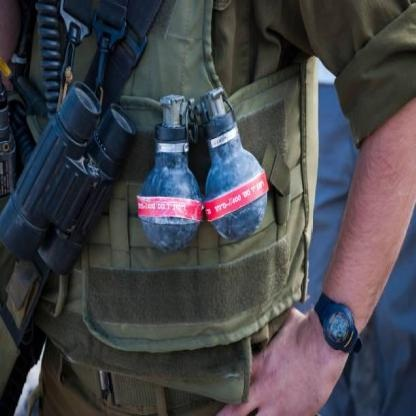

firearms-287f5a6280c0d71c.jpg


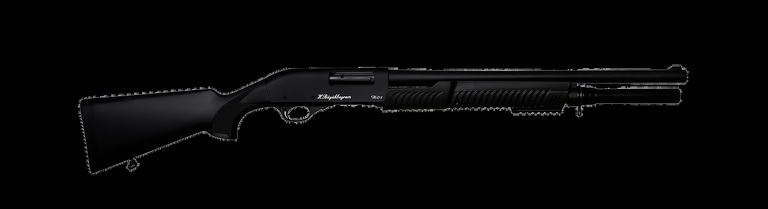

In [18]:
if failure_cases.empty:
    print("No primary-model multiclass misclassifications were recorded in test_predictions.csv.")
else:
    display(failure_cases.head(25))

def threshold_failure_type(row: pd.Series) -> str | None:
    flags = json.loads(str(row["threshold_flags"]))
    true_label = str(row["true_label"])
    if true_label == "safe" and any(bool(flags.get(label, False)) for label in restricted_labels):
        return "safe image crossed at least one restricted threshold"
    if true_label in restricted_labels and not bool(flags.get(true_label, False)):
        return "restricted image missed its own class threshold"
    return None


threshold_failure_labels = primary_predictions.apply(threshold_failure_type, axis=1)
threshold_failures = primary_predictions.loc[threshold_failure_labels.notna()].copy()
threshold_failures["failure_type"] = threshold_failure_labels.dropna()
print("Primary-model threshold failures:")
display(threshold_failures.head(25))

visual_failures = pd.concat([failure_cases, threshold_failures], ignore_index=True)
visual_failures = visual_failures.drop_duplicates(subset=["sample_id"])
if not visual_failures.empty:
    path_candidates = [
        column for column in visual_failures.columns
        if canonical_metric_name(column) in {"path", "image_path", "local_path", "file_path"}
    ]
    if path_candidates:
        shown = 0
        for raw_path in visual_failures[path_candidates[0]].dropna().astype(str):
            candidate = Path(raw_path)
            if not candidate.is_absolute():
                candidate = PROJECT_ROOT / candidate
            if candidate.is_file():
                print(candidate.name)
                display(NotebookImage(filename=str(candidate), width=420))
                shown += 1
            if shown >= 6:
                break


## 13A. Separately labeled external Wikimedia diagnostic

data/wikimedia_external_manifest.csv is not the formal training registry
and is not part of the untouched model test set. When the external
diagnostic outputs exist, this cell reports them as a small, manually
reviewed spot check with historical and keyword-search selection bias.


In [19]:
external_csv = EVALUATION_DIR / "external_spot_check.csv"
external_json = EVALUATION_DIR / "external_spot_check.json"
if external_csv.is_file() and external_json.is_file():
    external_rows = pd.read_csv(external_csv)
    external_summary = json.loads(external_json.read_text(encoding="utf-8"))
    print(external_summary.get("scope", "External diagnostic scope not recorded."))
    display(
        pd.DataFrame(
            [
                {"diagnostic_path": key, "value": value}
                for key, value in flatten_json(external_summary).items()
            ]
        )
    )
    display(external_rows.head(25))
elif external_csv.exists() or external_json.exists():
    raise FileNotFoundError(
        "External diagnostic is incomplete. Expected both "
        "outputs/evaluation/external_spot_check.csv and "
        "outputs/evaluation/external_spot_check.json."
    )
else:
    print("External diagnostic not run; no Wikimedia result is included.")


manually reviewed external Wikimedia diagnostic spot check; not a formal test set


,diagnostic_path,value
0,class_counts.explosives,5
1,class_counts.financial_promotion,3
2,class_counts.firearms,11
3,class_counts.safe,7
4,classification_report.accuracy,0.653846
5,classification_report.explosives.f1-score,0.222222
6,classification_report.explosives.precision,0.25
7,classification_report.explosives.recall,0.2
8,classification_report.explosives.support,5.0
9,classification_report.financial_promotion.f1-s...,0.5


,local_path,expected_label,classifier_prediction,policy_verdict,policy_primary_label,classifier_correct,weapon_detector_signal,detections_json,ocr_text,classifier_scores_json,fused_scores_json,review_reasons_json,classification_ms,detection_ms,ocr_ms,total_ms,annotated_path
0,data/wikimedia_pilot/train/safe/safe_train_9d2...,safe,safe,APPROVE,safe,True,True,"[{""label"": ""pistol"", ""score"": 0.34417280554771...",rational! = ® iss Se =! abe M AN CIT I 1B,"{""explosives"": 0.10095733537418054, ""financial...","{""explosives"": 0.1009573353741805, ""financial_...","[""Object context: pistol (0.34)""]",76.630125,5519.493667,270.958750,6150.345125,outputs/evaluation/external_annotated/00_safe_...
1,data/wikimedia_pilot/train/safe/safe_train_617...,safe,safe,APPROVE,safe,True,True,"[{""label"": ""bomb"", ""score"": 0.3163962960243225...",is \% Lk RY ox Dainty er Coven CANDY Clets Sce...,"{""explosives"": 0.10255210331767978, ""financial...","{""explosives"": 0.256292246760639, ""financial_p...","[""Object context: explosive device (0.36)"", ""O...",100.844084,4183.977375,207.594375,4496.313208,outputs/evaluation/external_annotated/01_safe_...
2,data/wikimedia_pilot/train/safe/safe_train_eb7...,safe,explosives,BLOCK,explosives,False,True,"[{""label"": ""fireworks"", ""score"": 0.36212703585...",Gut che! 'S Suppen- MAGG und Speisen- Wiirze —...,"{""explosives"": 0.3127430754684711, ""financial_...","{""explosives"": 0.43543815413089926, ""financial...","[""Object context: explosive device (0.37)"", ""e...",87.935958,5906.242666,317.348541,6315.989208,outputs/evaluation/external_annotated/02_safe_...
3,data/wikimedia_pilot/train/safe/safe_train_c45...,safe,explosives,BLOCK,explosives,False,True,"[{""label"": ""bomb"", ""score"": 0.3872989118099212...",THESHOE= 96 “BETTER THAN EVER AND STILLTHE BES...,"{""explosives"": 0.3241089977169525, ""financial_...","{""explosives"": 0.45302211047282737, ""financial...","[""Object context: explosive device (0.40)"", ""e...",87.302875,4734.014416,234.288583,5060.534083,outputs/evaluation/external_annotated/03_safe_...
4,data/wikimedia_pilot/val/safe/safe_val_8b0372d...,safe,safe,APPROVE,safe,True,False,[],=> om Un. Taye AK YOU il i I Drea 28 360) Birm...,"{""explosives"": 0.06247416203297338, ""financial...","{""explosives"": 0.0624741620329734, ""financial_...",[],100.764416,5046.055333,252.494125,5405.141250,outputs/evaluation/external_annotated/04_safe_...
5,data/wikimedia_pilot/val/safe/safe_val_b867666...,safe,safe,APPROVE,safe,True,True,"[{""label"": ""fireworks"", ""score"": 0.34453722834...","ED = HS, hy ee an <i Die as bf ‘a i oq o¥ ea G...","{""explosives"": 0.11271675709826089, ""financial...","{""explosives"": 0.1983133476930493, ""financial_...","[""Object context: fireworks (0.34)""]",92.237875,5043.827375,267.956750,5408.722208,outputs/evaluation/external_annotated/05_safe_...
6,data/wikimedia_pilot/test/safe/safe_test_5f865...,safe,safe,REVIEW,explosives,True,True,"[{""label"": ""ammunition bomb"", ""score"": 0.32440...",Het GROOTSLTE WONDER der Auto-Techniek is de 1...,"{""explosives"": 0.19145127628269049, ""financial...","{""explosives"": 0.39400018957716465, ""financial...","[""Object context: ammunition (0.32)"", ""Object ...",101.627708,4694.582416,330.495208,5132.199625,outputs/evaluation/external_annotated/06_safe_...
7,data/wikimedia_pilot/train/firearms/firearms_t...,firearms,firearms,REVIEW,firearms,True,True,"[{""label"": ""ammunition explosive device"", ""sco...",ttt IMPROVED PROTECTOR. ‘The new —— S sate PR ...,"{""explosives"": 0.3538279803735868, ""financial_...","{""explosives"": 0.48562827466382197, ""financial...","[""Object context: explosive device (0.42)"", ""R...",84.106875,5867.476042,173.358917,6129.992209,outputs/evaluation/external_annotated/07_firea...
8,data/wikimedia_pilot/train/firearms/firearms_t...,firearms,firearms,BLOCK,firearms,True,True,"[{""label"": ""pistol rifle shotgun"", ""score"": 0....","fl, = HOBOCTh bY By rs xt me 30) nosanesiesrs ..."

## 14. Optional single-image runtime smoke test

Set `AD_SAFETY_RUN_SMOKE=1` before starting Jupyter to exercise the saved
classifier through `ModerationEngine`. Detector, OCR, and explanation paths
remain separately opt-in because they add dependencies and latency. This
smoke test does not replace the held-out evaluation artifacts.


In [20]:
RUN_SMOKE = os.getenv("AD_SAFETY_RUN_SMOKE", "0") == "1"
if RUN_SMOKE:
    from ad_safety.inference import ModerationEngine

    test_rows = registry.loc[registry["split"].eq("test")]
    if test_rows.empty:
        raise RuntimeError("Runtime smoke test requires at least one registered test image.")
    sample_path = PROJECT_ROOT / str(test_rows.iloc[0]["local_path"])
    enable_detector = os.getenv("AD_SAFETY_ENABLE_DETECTOR", "0") == "1"
    enable_ocr = os.getenv("AD_SAFETY_ENABLE_OCR", "0") == "1"
    explain = os.getenv("AD_SAFETY_ENABLE_EXPLANATION", "0") == "1"

    engine = ModerationEngine(enable_detector=enable_detector)
    smoke = engine.analyze(
        sample_path,
        run_detector=enable_detector,
        run_ocr=enable_ocr,
        explain=explain,
    )
    display(pd.DataFrame([smoke.audit_record()["decision"]]))
    display(smoke.annotated_image)
    if smoke.heatmap_image is not None:
        display(smoke.heatmap_image)
else:
    print("Smoke test skipped. Set AD_SAFETY_RUN_SMOKE=1 to enable it.")


Smoke test skipped. Set AD_SAFETY_RUN_SMOKE=1 to enable it.


## 15. Run the local application

The classifier artifact `models/vit_policy_head.joblib` must exist before
either service starts. Detector and OCR are optional supporting paths.
From the repository root, run one service at a time in a terminal:

```bash
PYTHONPATH=src streamlit run app.py
```

```bash
PYTHONPATH=src uvicorn api:app --host 127.0.0.1 --port 8000
```

This notebook does not launch a persistent server. The dashboard is for
visual demonstration; the API supports programmatic integration and audit
records.


In [21]:
service_files = pd.DataFrame(
    [
        {"service": "Streamlit", "entrypoint": "app.py", "exists": (PROJECT_ROOT / "app.py").is_file()},
        {"service": "FastAPI", "entrypoint": "api.py", "exists": (PROJECT_ROOT / "api.py").is_file()},
    ]
)
display(service_files)
missing_services = service_files.loc[~service_files["exists"], "entrypoint"].tolist()
if missing_services:
    raise FileNotFoundError(f"Application entrypoints are missing: {missing_services}")


,service,entrypoint,exists
0,Streamlit,app.py,True
1,FastAPI,api.py,True


## 16. Evidence manifest and next steps

I keep final claims bounded to the saved evaluation manifest. Immediate
next steps are to complete visual label review, enlarge every split with
modern ad creatives and hard negatives, add source-held-out evaluation,
calibrate with more data, audit subgroup and domain behavior, test
production-like concurrency, and profile MPS memory and utilization in a
separately identified run. No pilot result should be promoted to a
production, fairness, fraud-detection, or attack-resistance claim.


In [22]:
manifest_flat = flatten_json(independent_validation)
display(
    pd.DataFrame(
        [{"manifest_path": key, "value": value} for key, value in manifest_flat.items()]
    )
)
display(output_checksums)

artifact_hashes = []
for relative in REQUIRED_EVALUATION_ARTIFACTS:
    path = PROJECT_ROOT / relative
    artifact_hashes.append(
        {
            "artifact": relative,
            "bytes": path.stat().st_size,
            "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
        }
    )
display(pd.DataFrame(artifact_hashes))


,manifest_path,value
0,all_checks_passed,True
1,artifacts.resnet50.path,models/resnet50_policy_head.joblib
2,artifacts.resnet50.reload_max_abs_probability_...,0.0
3,artifacts.resnet50.sha256,4690c0fc2c349811dfb14d8d450255bb2b54244a0a7e72...
4,artifacts.resnet50.trainable_backbone_parameters,0
5,artifacts.vit.path,models/vit_policy_head.joblib
6,artifacts.vit.reload_max_abs_probability_diffe...,0.0
7,artifacts.vit.sha256,3473f8f6817a007fe4ede49e10f571a6b1942c468c09df...
8,artifacts.vit.trainable_backbone_parameters,0
9,exact_hash_overlap_across_splits,0


,path,bytes,sha256
0,outputs/evaluation/benchmark_cpu_batch1.csv,564,61a07b4e713d66ae8ec7c9e4d6d780183e2ce86d4b99c0...
1,outputs/evaluation/confusion_matrix.csv,137,a1283b7f76525829a30f059f718aaad3d61a0e7619933b...
2,outputs/evaluation/confusion_matrix_resnet50.png,60452,c269549b7d3b36327aa3cccbd381385e7272dbb4150186...
3,outputs/evaluation/confusion_matrix_vit.png,56692,e401ee7aadc50a1a27ebbb7d692d0bf6eebfd976d239a9...
4,outputs/evaluation/dataset_contact_sheet.jpg,178052,c36d12aa0f4c41c2423098a04d4aeda87430b5b8a1fedd...
5,outputs/evaluation/dataset_distribution.png,38791,69eb6a033da2104301fcbefb83040bdce0d4e62a7e05c7...
6,outputs/evaluation/embeddings_resnet50.npz,1320149,66049dfa9acb65046d9f2af1e263ef95dd81b1aab47a07...
7,outputs/evaluation/embeddings_vit.npz,825676,000a858f86eaffbd20b5a84ef9938dddcd60684731e03e...
8,outputs/evaluation/evaluation_metrics.json,24673,ecfe9fa9a9fe20ed53e28763cd68f91bccd329ee9546f9...
9,outputs/evaluation/failure_cases.csv,604,30b9720b4eac4a2038c1227193d775bfccec567ec13660...


,artifact,bytes,sha256
0,outputs/evaluation/evaluation_metrics.json,24673,ecfe9fa9a9fe20ed53e28763cd68f91bccd329ee9546f9...
1,outputs/evaluation/independent_validation.json,828,8b96d44e20b514bda2d7dfe9dcf3854a5756e0a13092c0...
2,outputs/evaluation/per_class_metrics.csv,1197,cec1d87575c149427c5694aca2e2a9745051d293c78031...
3,outputs/evaluation/test_predictions.csv,27436,2a33f295888d620d662b26f4e4259c04ff63ef0d604e1e...
4,outputs/evaluation/thresholds.csv,905,56c6cbf99d17bd97de14e8e3c4eb56ad710e25ada86c6f...
5,outputs/evaluation/metrics_summary.csv,663,302b5a1f74cbfb86b696b3ef7562f32df25a6339bbdc93...
6,outputs/evaluation/benchmark_cpu_batch1.csv,564,61a07b4e713d66ae8ec7c9e4d6d780183e2ce86d4b99c0...
7,outputs/evaluation/split_summary.csv,717,ef10b78b86e58a6ffd164ab3cd68af375512a55955bc1f...
8,outputs/evaluation/output_checksums.csv,2895,f75b8d5b0f511ee9719e2850cd324b937d5e1b7a3f4b67...
9,outputs/evaluation/dataset_distribution.png,38791,69eb6a033da2104301fcbefb83040bdce0d4e62a7e05c7...


## References

- Dosovitskiy et al., *An Image is Worth 16x16 Words*, ICLR 2021:
  https://openreview.net/forum?id=YicbFdNTTy
- He et al., *Deep Residual Learning for Image Recognition*, CVPR 2016:
  https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html
- Liu et al., *Grounding DINO*, ECCV 2024:
  https://arxiv.org/abs/2303.05499
- Formal dataset provenance, source groups, revisions, hashes, and license
  evidence are recorded per image in `data/capstone_registry.csv`.
- `data/wikimedia_external_manifest.csv` is an external diagnostic
  manifest, not a training or formal test registry.
- Project scope originates in `Capstone Project Idea - Ad Safety.pdf`.
